# Cybersecurity Job Market Analysis (EDA)

This notebook explores cybersecurity job listing collected through web scraping

## Objectives:
- Understand job market trends
- Identify top hiring companies
- Analyze in-demand skills
- Detect data issues

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
df=pd.read_csv(r"C:\Users\Student\Desktop\cyber_job_scraper\data\processed\cybersecurity_jobs.csv")
df.head()

,title,company,location,skills
0,Associate Forward Deployed Engineer,Symmetry Systems,Remote,"saas, security, training, technical, code, clo..."
1,Product Security Manager,MoonPay,United States (East Coast Time Zone) - Remote,"security, manager, design, web3, crypto, syste..."
2,Cloud Security Engineer,MoonPay,NaN,"security, crypto, system, swift, training, tec..."
3,Senior Security Engineer Automation,MoonPay,NaN,"security, crypto, system, swift, training, tec..."
4,Associate Director CMC,Allucent,NaN,"director, training, consulting, technical, sup..."


In [3]:
print("shape:",df.shape)
df.info()

shape: (5, 4)
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   title     5 non-null      str  
 1   company   5 non-null      str  
 2   location  2 non-null      str  
 3   skills    5 non-null      str  
dtypes: str(4)
memory usage: 292.0 bytes


In [4]:
df.describe(include="all")

,title,company,location,skills
count,5,5,2,5
unique,5,3,2,5
top,Associate Forward Deployed Engineer,MoonPay,Remote,"saas, security, training, technical, code, clo..."
freq,1,3,1,1


In [5]:
print("missing values:\n",df.isnull().sum())
print("\n duplicate rows :",df.duplicated().sum())

missing values:
 title       0
company     0
location    3
skills      0
dtype: int64

 duplicate rows : 0


## Key Questions
- Which companies hire the most cybersecurity professionals?
- What are the most common job roles?
- What skills are most in demand?
- Are there data quality issues?


In [13]:
top_companies=df["company"].value_counts().head()
top_companies

company
MoonPay             3
Symmetry Systems    1
Allucent            1
Name: count, dtype: int64

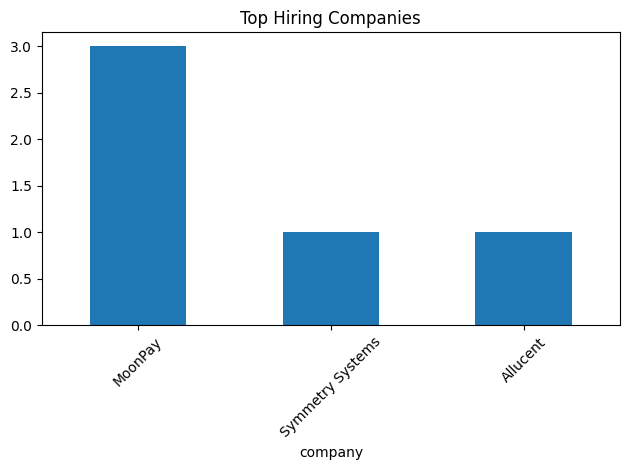

In [14]:
top_companies.plot(kind="bar")
plt.title("Top Hiring Companies")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
top_titles=df["title"].value_counts().head()
top_titles

title
Associate Forward Deployed Engineer    1
Product Security Manager               1
Cloud Security Engineer                1
Senior Security Engineer Automation    1
Associate Director CMC                 1
Name: count, dtype: int64

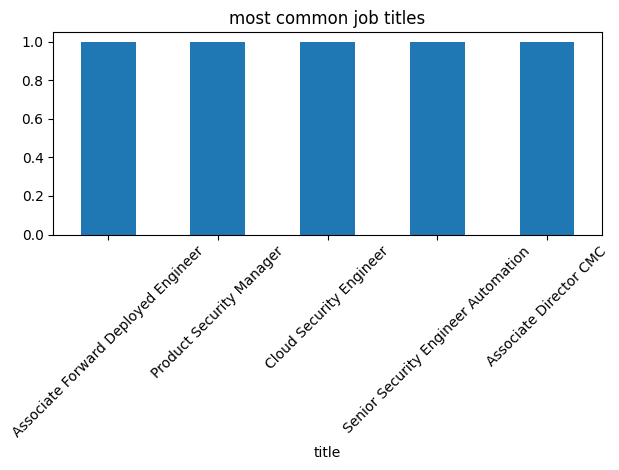

In [16]:
top_titles.plot(kind="bar")
plt.title("most common job titles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
all_skills=" ,".join(df["skills"]).lower().split(",")
all_skills=[skill.strip() for skill in all_skills]
skills_count=Counter(all_skills)
top_skills=pd.DataFrame(skills_count.most_common(),columns=["skill","count"])

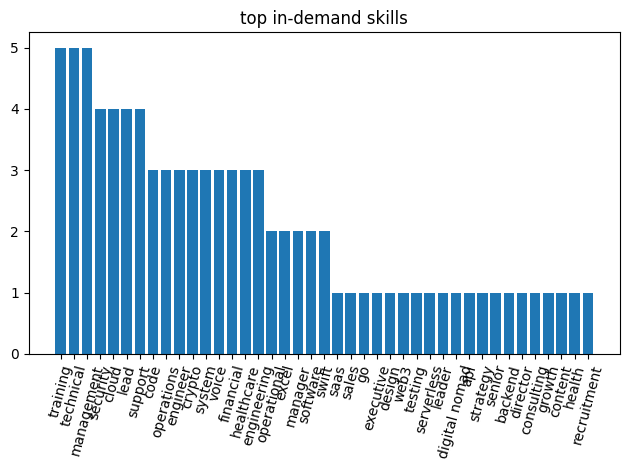

In [18]:
plt.bar(top_skills["skill"],top_skills["count"])
plt.title("top in-demand skills")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

# Dataset  Overview
The dataset is relatively small, which may limit generalization, but it still provides useful insights into cybersecurity roles.

# Technical + Management dominate

The job market is not only technical but also strongly management-oriented, indicating demand for professionals who can both execute and lead.

# Soft + Operational skills matter

Also see:

support

operations

leadership

strategy

This shows cybersecurity roles require communication and operational coordination, not just coding.

# Cloud + System roles appear frequently

Even if not top 1–3 visually, skills like:

system

cloud

engineering

software

indicate strong demand for cloud-based cybersecurity expertise.

# Issues noticed:

- Skills are not standardized (e.g., "technical", "training", "support" are generic)
- Some words are job-related soft skills, not real technical skills
- Skills are comma-separated → not normalized

## Skills Analysis Insight

The dataset shows that cybersecurity job postings emphasize a combination of technical, operational, and managerial skills. However, the skills column contains noise and non-standardized entries, which suggests the need for better data cleaning and skill normalization in further improvements.

In [6]:
VALID_SKILLS = [
    "security", "cyber", "soc", "infosec", "devsecops",
    "penetration", "network", "cloud", "aws", "azure",
    "python", "linux", "docker", "kubernetes",
    "api", "firewall", "malware", "threat",
    "vulnerability", "incident", "forensics"]

In [7]:
def clean_skills(text):
    if pd.isna(text):
        return []
    text = text.lower()
    found_skills = []
    for skill in VALID_SKILLS:
        if skill in text:
            found_skills.append(skill)
    return found_skills

In [8]:
df["clean_skills"] = df["skills"].apply(clean_skills)
df[["title", "clean_skills"]].head()

,title,clean_skills
0,Associate Forward Deployed Engineer,"[security, cloud]"
1,Product Security Manager,"[security, cloud]"
2,Cloud Security Engineer,"[security, cloud]"
3,Senior Security Engineer Automation,"[security, cloud, api]"
4,Associate Director CMC,[]


In [9]:
all_skills = sum(df["clean_skills"], [])
skill_counts = Counter(all_skills)
top_skills = pd.DataFrame(skill_counts.most_common(10),columns=["Skill", "Count"])
top_skills

,Skill,Count
0,security,4
1,cloud,4
2,api,1


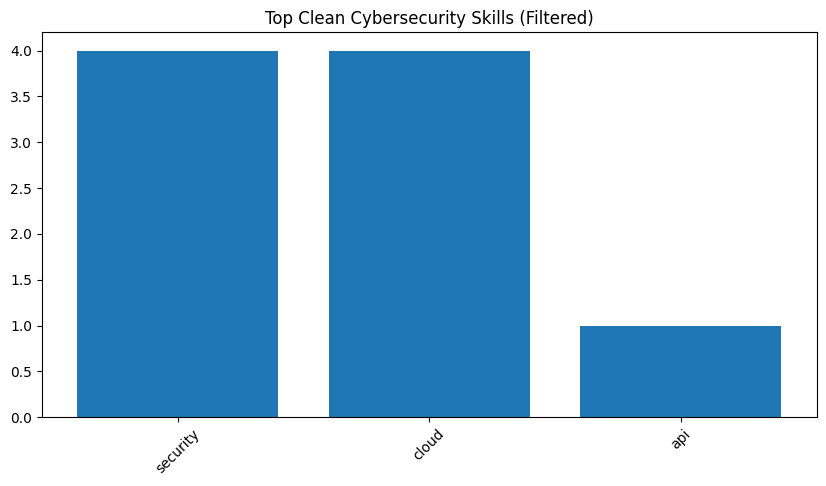

In [10]:
plt.figure(figsize=(10,5))
plt.bar(top_skills["Skill"], top_skills["Count"])
plt.title("Top Clean Cybersecurity Skills (Filtered)")
plt.xticks(rotation=45)
plt.show()

## Clean Skill Analysis

After applying a skill classification filter, the dataset shows more accurate cybersecurity skill trends. Generic and non-technical terms were removed to focus only on real cybersecurity competencies.

Key insights:
- Security and cloud-related skills dominate job requirements
- Python and Linux are important technical foundations
- DevSecOps and DevOps concepts are emerging in job listings

In [11]:
engineer_jobs=df["title"].str.contains("engineer",case=False).sum()
analyst_jobs=df["title"].str.contains("analyst",case=False).sum()
print("Engineer jobs:",engineer_jobs)
print("Analyst jobs:",analyst_jobs)

Engineer jobs: 3
Analyst jobs: 0


The dataset shows a strong preference for engineering roles over analyst roles in cybersecurity.

In [12]:
df["location"].value_counts().head()

location
Remote                                           1
United States (East Coast Time Zone) - Remote    1
Name: count, dtype: int64

A significant portion of job listings lack location data, which may affect geographical analysis.


Most jobs appear to be remote-based, but missing data limits deeper location insights.

## Observations

- A few companies dominate cybersecurity hiring.
- Engineering roles appear more frequently than analyst roles.
- Skills like security, cloud, and API are highly demanded.
- Some data contains missing or non-cyber roles.

## Conclusion

This analysis highlights key trends in the cybersecurity job market:

- High demand for security engineers
- Strong focus on cloud and API-related skills
- Remote jobs dominate listings

Further improvements can include:
- Better filtering of cybersecurity-specific roles
- Expanding data sources